In [1]:
!mamba install pandas numpy matplotlib seaborn scikit-learn

mambajs 0.19.13

Specs: xeus-python, numpy, matplotlib, pillow, ipywidgets>=8.1.6, ipyleaflet, scipy, pandas, seaborn, scikit-learn
Channels: emscripten-forge, conda-forge

Solving environment...
Solving took 7.374699999988079 seconds
  Name                          Version                       Build                         Channel                       
────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────
+ brotli-python                 1.2.0                         py313h33caa6c_0               emscripten-forge              
+ certifi                       2026.2.25                     pyhd8ed1ab_0                  conda-forge                   
+ charset-normalizer            3.4.7                         pyhd8ed1ab_0                  conda-forge                   
+ idna                          3.11                          pyhd8ed1ab_0                  conda-forge                   
+ joblib                     

In [109]:
import pandas as pd
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('https://raw.githubusercontent.com/CunyLaguardiaDataAnalytics/datasets/master/2014-15_To_2016-17_School-_Level_NYC_Regents_Report_For_All_Variables.csv')

In [4]:
df.head() #looking at the datafram

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
0,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Common Core Algebra,2017,4,s,s,s,s,s,s,s,na,na
1,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2015,16,77.9,1,6.3,15,93.8,7,43.8,na,na
2,01M034,P.S. 034 Franklin D. Roosevelt,K-8,Living Environment,2016,9,74,1,11.1,8,88.9,2,22.2,na,na
3,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2016,3,s,s,s,s,s,s,s,na,na
4,01M140,P.S. 140 Nathan Straus,K-8,Common Core Algebra,2017,2,s,s,s,s,s,s,s,na,na


In [6]:
#M - Manhattan, X - Bronx, K - Brooklyn, Q - Queens, R - Staten Island
#to create a new column to show specific boroughs based on School DBN info
# Create mapping dictionary
borough_map = {
    'K': 'Brooklyn',
    'X': 'Bronx',
    'M': 'Manhattan',
    'R': 'Staten Island',
    'Q': 'Queens'
}

# Extract the letter and define using mapping dictionary into new column
df['Borough'] = df['School DBN'].str.extract(r'([KXMRQ])')[0].map(borough_map)

In [7]:
df.groupby(['Borough']).count()

,School DBN,School Name,School Level,Regents Exam,Year,Total Tested,Mean Score,Number Scoring Below 65,Percent Scoring Below 65,Number Scoring 65 or Above,Percent Scoring 65 or Above,Number Scoring 80 or Above,Percent Scoring 80 or Above,Number Scoring CR,Percent Scoring CR
Borough,,,,,,,,,,,,,,,
Bronx,54051,54051,54051,54051,54051,54051,54051,54051,54051,54051,54051,54051,54051,54051,54051
Brooklyn,63645,63645,63645,63645,63645,63645,63645,63645,63645,63645,63645,63645,63645,63645,63645
Manhattan,48502,48502,48502,48492,48502,48502,48502,48502,48502,48502,48502,48502,48502,48502,48502
Queens,39633,39633,39633,39633,39633,39633,39633,39633,39633,39633,39633,39633,39633,39633,39633
Staten Island,6500,6500,6500,6500,6500,6500,6500,6500,6500,6500,6500,6500,6500,6500,6500


In [49]:
#defining columns to drop and dropping from df
drop_cols = ['Number Scoring CR', 'Percent Scoring CR']
df.drop(drop_cols, inplace = True, axis=1)

In [62]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 212331 entries, 0 to 212330
Data columns (total 14 columns):
 #   Column                       Non-Null Count   Dtype
---  ------                       --------------   -----
 0   School DBN                   212331 non-null  str  
 1   School Name                  212331 non-null  str  
 2   School Level                 212331 non-null  str  
 3   Regents Exam                 212321 non-null  str  
 4   Year                         212331 non-null  int64
 5   Total Tested                 212331 non-null  int64
 6   Mean Score                   212331 non-null  str  
 7   Number Scoring Below 65      212331 non-null  str  
 8   Percent Scoring Below 65     212331 non-null  str  
 9   Number Scoring 65 or Above   212331 non-null  str  
 10  Percent Scoring 65 or Above  212331 non-null  str  
 11  Number Scoring 80 or Above   212331 non-null  str  
 12  Percent Scoring 80 or Above  212331 non-null  str  
 13  Borough                      212331 non-

In [75]:
#columns to convert to numeric
cols = ['Mean Score', 'Number Scoring Below 65', 'Percent Scoring Below 65', 'Number Scoring 65 or Above', 'Percent Scoring 65 or Above', 'Number Scoring 80 or Above', 'Percent Scoring 80 or Above']
df[cols] = df[cols].apply(pd.to_numeric, errors='coerce')

In [114]:
#dropping rows that have NaN in Mean Score
df = df.dropna(subset=['Mean Score'])

In [100]:
#creating dataframe for high schools only looking at the geometry regents in year 2016
hs_geo2016 = df[
    (df['Regents Exam'] == 'Geometry') &
    (df['School Level'] == 'High school') &
    (df['Year'] == 2016)
]


In [123]:
#finding the mean per borough for 3 specific columns
summary = hs_geo2016.groupby('Borough')[['Percent Scoring Below 65', 'Percent Scoring 65 or Above', 'Percent Scoring 80 or Above']].mean()

print(summary)

               Percent Scoring Below 65  Percent Scoring 65 or Above  \
Borough                                                                
Bronx                         76.404091                    23.596818   
Brooklyn                      72.737313                    27.264677   
Manhattan                     64.786842                    35.213684   
Queens                        74.626887                    25.375943   
Staten Island                 81.625532                    18.374468   

               Percent Scoring 80 or Above  
Borough                                     
Bronx                             4.546818  
Brooklyn                          3.884080  
Manhattan                         8.313684  
Queens                            3.238679  
Staten Island                     0.863830  


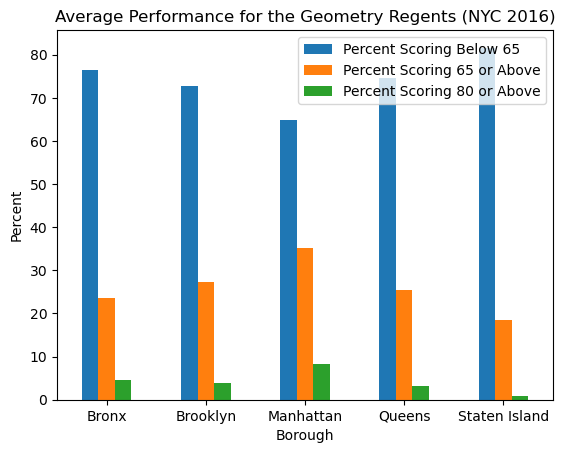

In [125]:
summary.plot(kind='bar')

plt.title('Average Performance for the Geometry Regents (NYC 2016)')
plt.ylabel('Percent')
plt.xticks(rotation=0)
plt.show()

#based on the chart that is displayed, Manhattan had the highest percentage of schools scoring higher 80 or above and 65 and above in 2016
#Staten Island, had the highest percentage of high schools scoring below 65 and the lowest percent scoring 80 or above in 2016
#Bronx, Brooklyn and Queens had similar averages across the scoring types